# Module `algorithms/dynamic_benchmark.py`

Harnais dedie a l'evaluation des strategies dynamiques. Contrairement au benchmark statique, on fait varier **deux** graines independantes :

- `instance_seeds` : variabilite du graphe.
- `sim_seeds` : variabilite de la trajectoire dynamique pour une meme instance.

Pour chaque `(taille, inst_seed, sim_seed, algo)` on execute une ou plusieurs strategies parmi :

- `fixed` : plan initial suivi jusqu'au bout ;
- `reopt` : re-resolution complete (solveur lourd) a chaque retour depot ;
- `reactive` : 2-opt a chaque sommet + `local_search` au depot, aucun appel solveur lourd apres l'init.

Le parametre `strategy_kwargs` permet de passer des options par strategie (ex. `adaptive_budget=True` pour `reopt`).


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent / "src"))

from cesipath.algorithms import (
    grasp,
    plot_dynamic_cost_comparison,
    plot_dynamic_gain,
    plot_dynamic_planned_vs_realized,
    plot_dynamic_reactive_gain,
    run_dynamic_benchmark,
    simulated_annealing,
    summarize_dynamic_benchmark,
    tabu_search,
)


## 1. Schema d'une ligne de benchmark dynamique

Chaque dict produit par `run_dynamic_benchmark` porte :

| Cle | Signification |
|---|---|
| `size` | Taille du graphe |
| `instance_seed` | Graine du `GraphGenerator` |
| `sim_seed` | Graine du simulateur dynamique |
| `algo` | Nom de l'algo dans `algos` |
| `strategy` | `"fixed"`, `"reopt"` ou `"reactive"` |
| `planned_cost` | Cout du plan initial (step 0) |
| `realized_cost` | Cout reel paye en dynamique |
| `reoptimizations` | Nombre total d'interventions (init + replans) |
| `depot_replans` | Replans declenches au retour depot |
| `reactive_repairs` | Passes 2-opt ayant modifie le suffixe en cours de route (strategie `reactive`) |
| `solver_time` | Temps cumule passe dans le solveur + local_search |
| `steps` | Nombre total de transitions |


## 2. Lancer un benchmark reduit

On garde des parametres tres modestes car chaque couple (instance, sim, algo, strategie) execute un solveur potentiellement plusieurs fois.


In [ ]:
algos = {
    "grasp": grasp,
    "sa":    simulated_annealing,
    "tabu":  tabu_search,
}
algo_kwargs = {
    "grasp": {"max_iterations": 10, "rcl_alpha": 0.3},
    "sa":    {"max_iterations": 400, "cooling_rate": 0.95},
    "tabu":  {"max_iterations": 40, "tabu_tenure": 7},
}

results = run_dynamic_benchmark(
    sizes=[15, 30, 50],
    instance_seeds=[6, 7],
    sim_seeds=[10, 20],
    algos=algos,
    algo_kwargs=algo_kwargs,
    strategies=("fixed", "reopt", "reactive"),
    verbose=False,
)
print(f"{len(results)} lignes")
print("exemple :", results[0])


72 lignes
exemple : {'size': 8, 'instance_seed': 1, 'sim_seed': 10, 'algo': 'grasp', 'strategy': 'fixed', 'planned_cost': 672.75, 'realized_cost': 699.12, 'reoptimizations': 1, 'solver_time': 0.0007, 'steps': 11, 'depot_replans': 0, 'reactive_repairs': 0}


## 3. Resume agrege

`summarize_dynamic_benchmark` agrege par `(size, algo, strategy)` : moyenne des couts planifies et realises, min/max du cout realise, temps moyen, nombre moyen d'interventions et leur decomposition (`depot_replans_mean`, `reactive_repairs_mean`).


In [3]:
summary = summarize_dynamic_benchmark(results)
header = f"{'size':>4}  {'algo':<6}  {'strat':<8}  {'planned':>8}  {'realized':>8}  {'time':>6}  {'depot':>5}  {'react':>5}"
print(header)
for row in summary:
    print(f"{row['size']:>4}  {row['algo']:<6}  {row['strategy']:<8}  "
          f"{row['planned_mean']:>8.2f}  {row['realized_mean']:>8.2f}  "
          f"{row['solver_time_mean']:>6.3f}  "
          f"{row['depot_replans_mean']:>5.2f}  {row['reactive_repairs_mean']:>5.2f}")


size  algo    strat      planned  realized    time  depot  react
   8  grasp   fixed       789.58    878.91   0.001   0.00   0.00
   8  grasp   reactive    789.58    934.13   0.001   3.00   0.00
   8  grasp   reopt       789.58    919.44   0.002   3.00   0.00
   8  sa      fixed       789.58    874.75   0.001   0.00   0.00
   8  sa      reactive    789.58    928.29   0.001   3.00   0.00
   8  sa      reopt       789.58    915.59   0.003   3.00   0.00
   8  tabu    fixed       789.58    883.28   0.001   0.00   0.00
   8  tabu    reactive    789.58    934.10   0.001   3.00   0.00
   8  tabu    reopt       789.58    902.86   0.002   3.00   0.00
  12  grasp   fixed       594.59    677.49   0.001   0.00   0.00
  12  grasp   reactive    594.59    681.57   0.001   0.50   0.25
  12  grasp   reopt       594.59    686.93   0.001   0.50   0.00
  12  sa      fixed       618.02    767.13   0.001   0.00   0.00
  12  sa      reactive    618.02    706.19   0.001   0.50   1.50
  12  sa      reopt      

## 4. Figure 1 : cout realise par strategie

`plot_dynamic_cost_comparison` : un sous-graphe par taille, barres groupees par strategie, une couleur par algo. Lecture : la strategie `reopt` devrait en general produire des barres plus basses que `fixed`, mais elle consomme aussi plus de temps solveur.


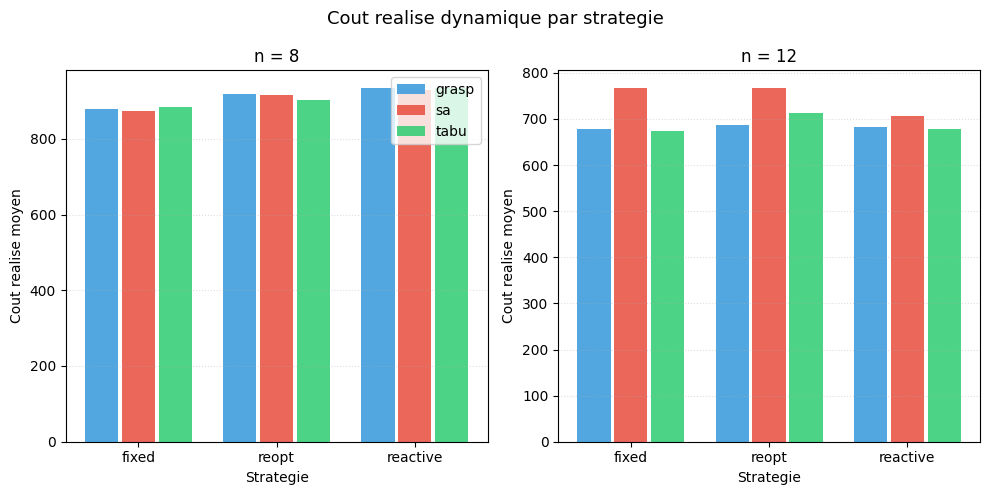

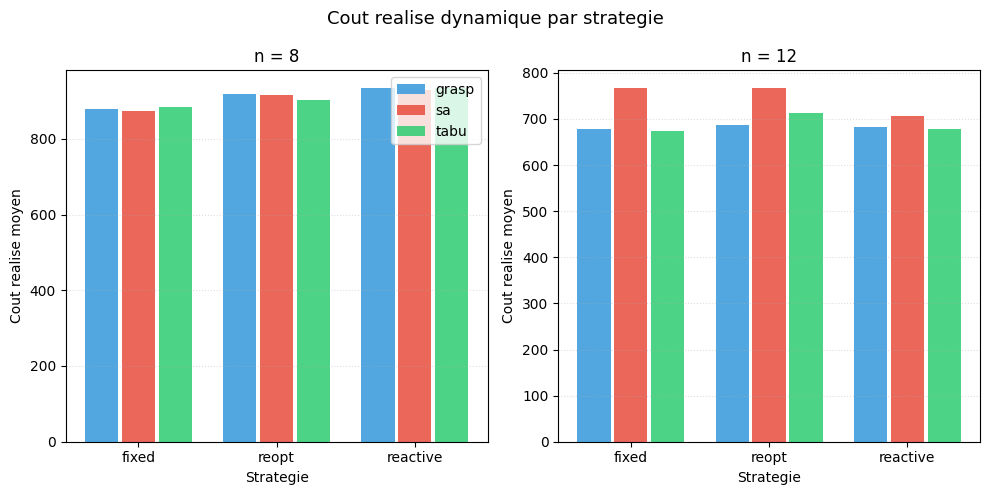

In [4]:
fig = plot_dynamic_cost_comparison(results)
fig


## 5. Figure 2 : gain relatif de la re-optimisation

`plot_dynamic_gain` trace le boxplot de

```
gain = 100 * (fixed - reopt) / fixed
```

Positif = la re-optimisation a ete payante. Un gain centre autour de 0 signifie que la strategie plan-fige est deja suffisante sur cette instance (les perturbations sont faibles ou bien tolerees). Un gain largement positif signale que la dynamique perturbe suffisamment pour justifier le cout de re-resolution.

**Note** : la figure compare `fixed` vs `reopt`. Le notebook calcule juste apres le meme indicateur pour `reactive` vs `fixed`, pour completer la lecture sans modifier la fonction `plot_dynamic_gain`.


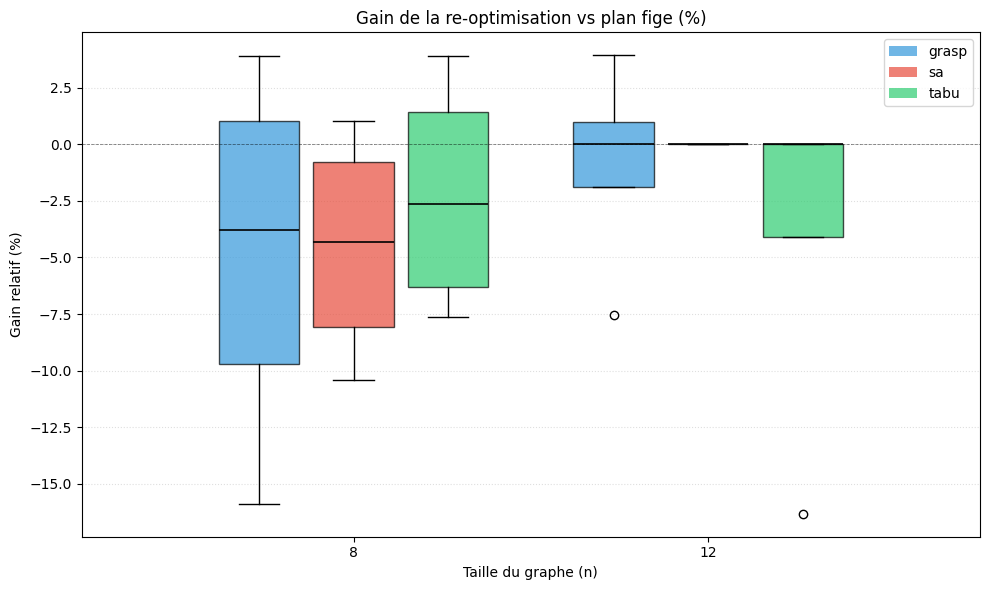

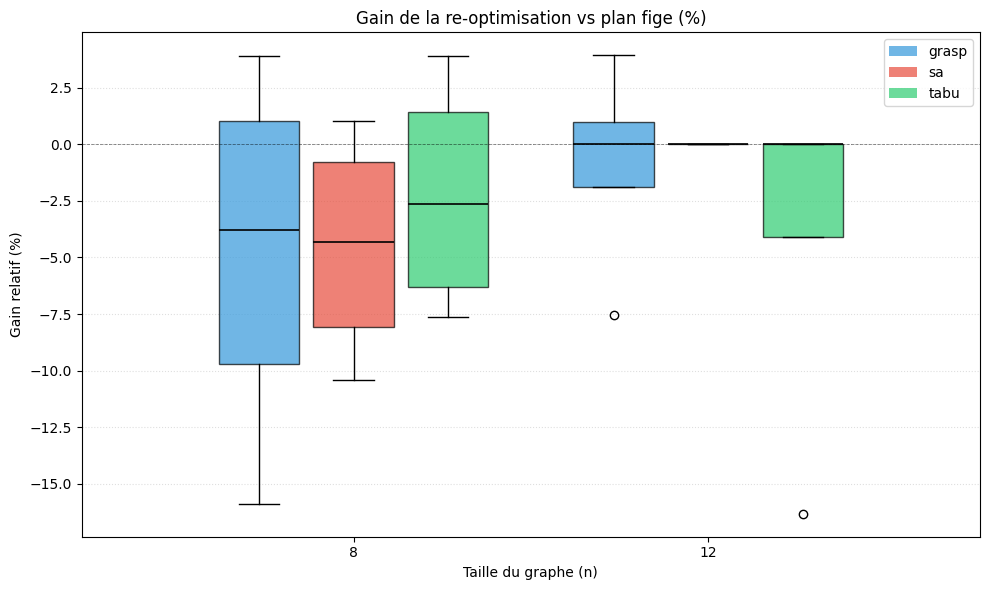

In [5]:
fig = plot_dynamic_gain(results)
fig


## 6. Figure 3 : gain relatif de `reactive` vs plan fige

`plot_dynamic_reactive_gain` trace le boxplot de

```
gain = 100 * (fixed - reactive) / fixed
```

Positif = `reactive` reduit le cout realise par rapport au plan fige. Negatif = les reparations locales ont fait pire que `fixed` sur cet echantillon.


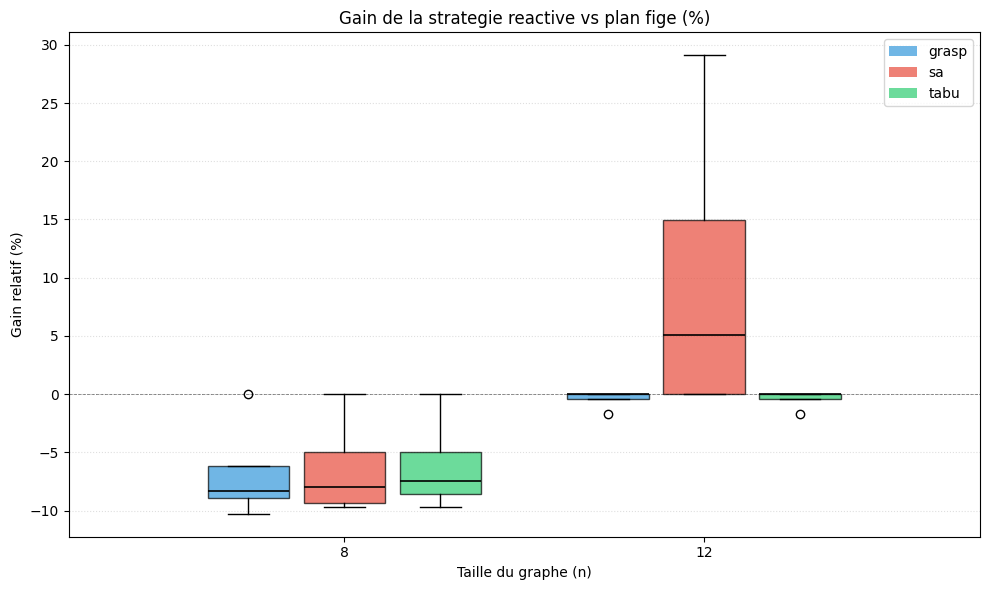

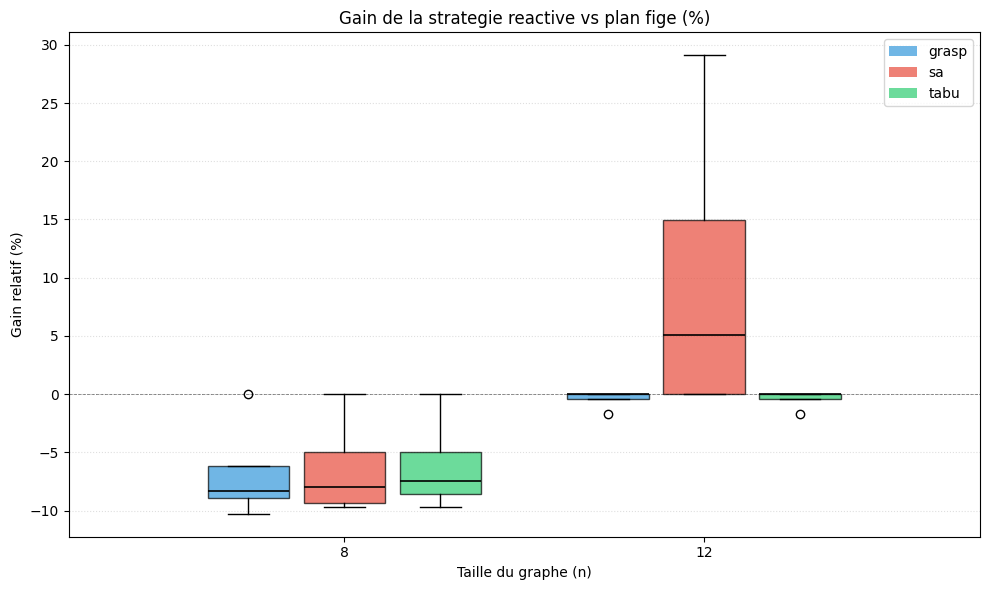

In [6]:
fig = plot_dynamic_reactive_gain(results)
fig


## 7. Figure 4 : cout planifie vs cout realise

`plot_dynamic_planned_vs_realized` : nuage de points avec la diagonale `y = x` en pointilles. Les points **au-dessus** de la diagonale indiquent que le cout reel depasse l'estimation initiale (cas general). Un algo robuste aura un nuage proche de la diagonale.


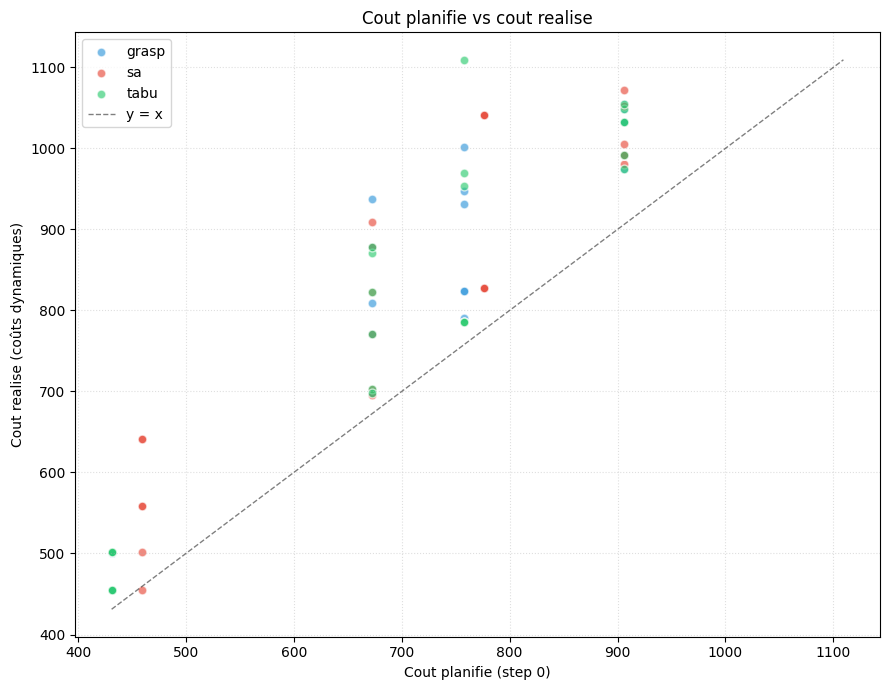

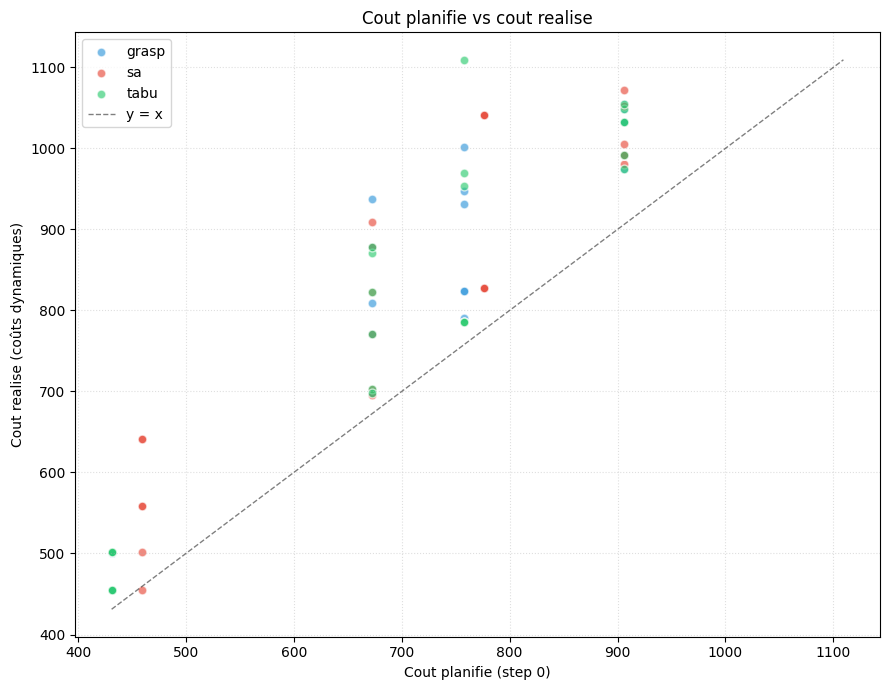

In [7]:
fig = plot_dynamic_planned_vs_realized(results)
fig


## 8. Sauvegarde des figures

`save_dynamic_benchmark_figures(results)` ecrit quatre PNG (`dynamic_cost_N.png`, `dynamic_gain_N.png`, `dynamic_reactive_gain_N.png`, `dynamic_scatter_N.png`) dans `algorithms/image/` avec un index auto-incremente. Le dossier est dans `.gitignore` : **pas de commit de PNG**.


## 9. Conseils pour un benchmark dynamique serieux

- **Dissocier les graines**. Varier `sim_seeds` pour une meme instance isole l'effet de la dynamique de l'effet de la topologie.
- **Meme budget solveur**. Le temps `solver_time` cumule depend du nombre de reoptimisations pour `reopt` ; pour une comparaison honnete, donner aux strategies `reopt` un budget par appel compatible. `reactive` n'a pas ce probleme (un seul appel solveur).
- **Plus de repetitions sur petites tailles**. Le bruit est grand : 5 x 5 graines produit deja 25 executions par (algo, strategie).
- **`reactive` change la donne pour le GA**. Avec `reopt`, le GA domine en temps (depot_replans * cout_GA). Avec `reactive`, le temps total est proche de `fixed`. A tailles > 40, le speedup observe est de l'ordre de x5 a x7.
